# Inpainting – Usuwanie Miarek z Obrazów USG

## 1. Przegląd bibliotek do inpaintingu

W pracy analizujemy głównie cztery biblioteki i podejścia do inpaintingu. **OpenCV** posiada dwie metody. Pierwsza to Telea (oparty na Fast Marching Method - FMM), implementowany przez flagę `cv2.INPAINT_TELEA`. Jest to metoda szybka i dobra do usuwania cienkich linii, takich jak miarki USG. Druga metoda to Navier-Stokes (`cv2.INPAINT_NS`), który modeluje przepływ płynów i jest bardziej odpowiedni dla dużych obszarów do inpaintingu. **scikit-image** udostępnia metodę Biharmonic (`inpaint_biharmonic`), która zapewnia najwyższą jakość rezultatów dzięki C2-ciągłości, jednak jest znacznie wolniejsza od metod OpenCV. **SimpleITK** nie oferuje bezpośrednio funkcjonalności inpaintingu, jednak jest używane głównie do preprocessingu obrazów DICOM i wczytywania danych medycznych. **LaMa** (Learning to Inpaint with Fast Fourier Convolutions) to podejście oparte na sieciach neuronowych, wykorzystujące Fast Fourier Convolutions (FFConv) oraz platformę `lama-cleaner`. Jest to metoda SOTA (State-of-the-Art), jednak wymaga GPU do efektywnego działania.

**Wybrana metoda główna:** Telea (r=7), kompromis jakości i szybkości dla linii miarek USG.

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.restoration import inpaint_biharmonic
import warnings
warnings.filterwarnings('ignore')

## 2. Wczytanie i analiza przykładowego obrazu

Size: 1016x708 px

Pixels with B-R>40 & B>80: 630
Pixels with B-G>40 & B>80: 221
Pixels with G-R>40 & G>80: 59
Pixels with R-B>40 & R>80: 454


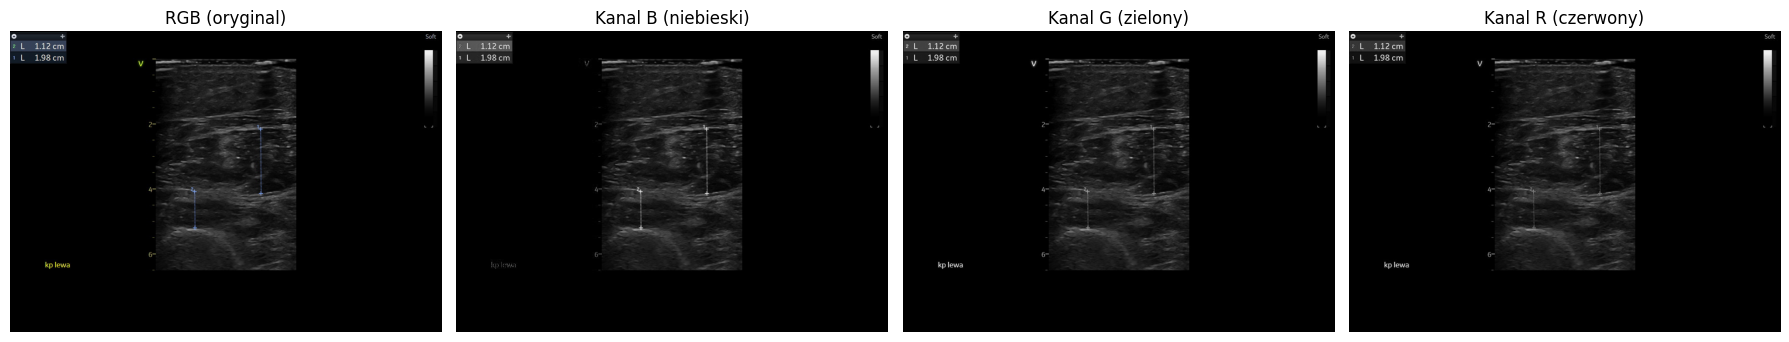

In [24]:
INPUT_DIR  = Path('images')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

EXAMPLE = INPUT_DIR / '21.G.R 3.jpg'
img_bgr  = cv2.imread(str(EXAMPLE))
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f'Size: {img_bgr.shape[1]}x{img_bgr.shape[0]} px')

b, g, r = img_bgr[:,:,0], img_bgr[:,:,1], img_bgr[:,:,2]

cand = ((b.astype(int)-r.astype(int) > 40) & (b > 80)).sum()
cand_bg = ((b.astype(int)-g.astype(int) > 40) & (b > 80)).sum()
cand_gr = ((g.astype(int)-r.astype(int) > 40) & (g > 80)).sum()
cand_rb = ((r.astype(int)-b.astype(int) > 40) & (r > 80)).sum()
print(f'\nPixels with B-R>40 & B>80: {cand}')
print(f'Pixels with B-G>40 & B>80: {cand_bg}')
print(f'Pixels with G-R>40 & G>80: {cand_gr}')
print(f'Pixels with R-B>40 & R>80: {cand_rb}')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, im, t in zip(axes,
    [img_rgb, b, g, r],
    ['RGB (oryginal)', 'Kanal B (niebieski)', 'Kanal G (zielony)', 'Kanal R (czerwony)']):
    ax.imshow(im, cmap='gray' if t!='RGB (oryginal)' else None)
    ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Segmentacja miarek

Obserwacja pokazuje, że miarki USG maja wyrazna dominacje kanalu B w przestrzeni BGR co pokazują pomiary kanałów dla obrazów

**Strategia segmentacji:** polega na maskach koloru `B − R > 30` AND `B − G > 20` AND `B > 80` - selektywnie wyodrębnia niebieskie piksele miarek oraz dylatacji morfologicznej (jadro eliptyczne 7×7, 2 iteracje, łaczy przerwy w linii przerywanej i pokrywa grubosc linii)

Pokrycie maski: 1.512%


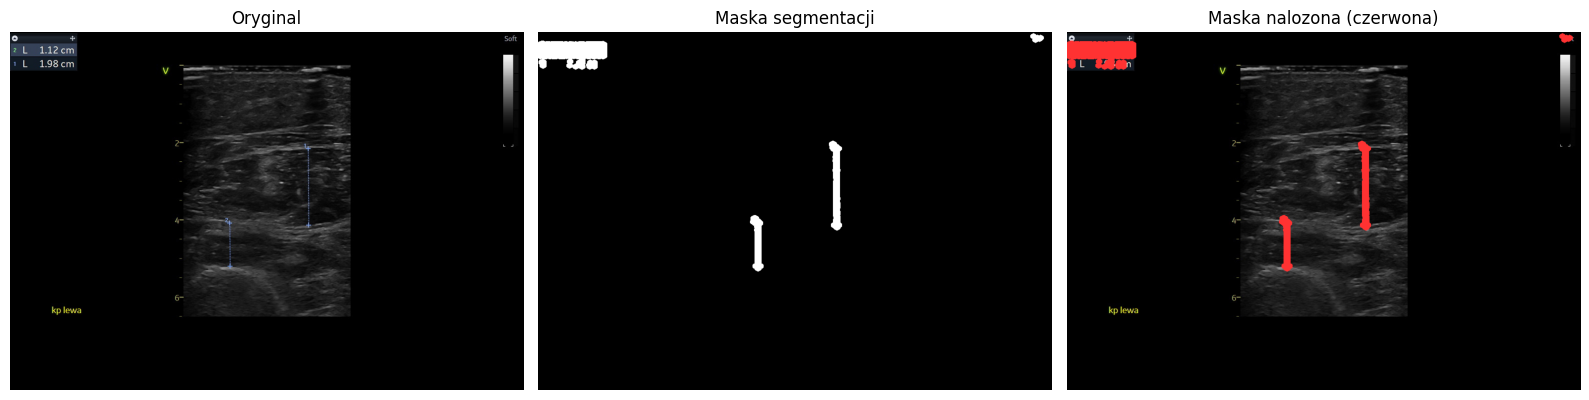

In [25]:
SEG_PARAMS = dict(
    b_minus_r_thresh = 30,
    b_minus_g_thresh = 20,
    b_min_val        = 80,
    dilate_k         = 7,
    dilate_iter      = 2,
)

def segment_calipers(img_bgr, p):
    b = img_bgr[:,:,0].astype(np.int16)
    g = img_bgr[:,:,1].astype(np.int16)
    r = img_bgr[:,:,2].astype(np.int16)
    mask = (
        (b - r > p['b_minus_r_thresh']) &
        (b - g > p['b_minus_g_thresh']) &
        (img_bgr[:,:,0] > p['b_min_val'])
    ).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (p['dilate_k'], p['dilate_k']))
    return cv2.dilate(mask, kernel, iterations=p['dilate_iter'])

mask = segment_calipers(img_bgr, SEG_PARAMS)
overlay = img_rgb.copy()
overlay[mask > 0] = [255, 50, 50]
coverage = 100 * float(mask.sum()) / (255.0 * mask.size)
print(f'Pokrycie maski: {coverage:.3f}%')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, im, t in zip(axes,
    [img_rgb, mask, overlay],
    ['Oryginal', 'Maska segmentacji', 'Maska nalozona (czerwona)']):
    ax.imshow(im, cmap='gray' if t == 'Maska segmentacji' else None)
    ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Inpainting – porownanie metod

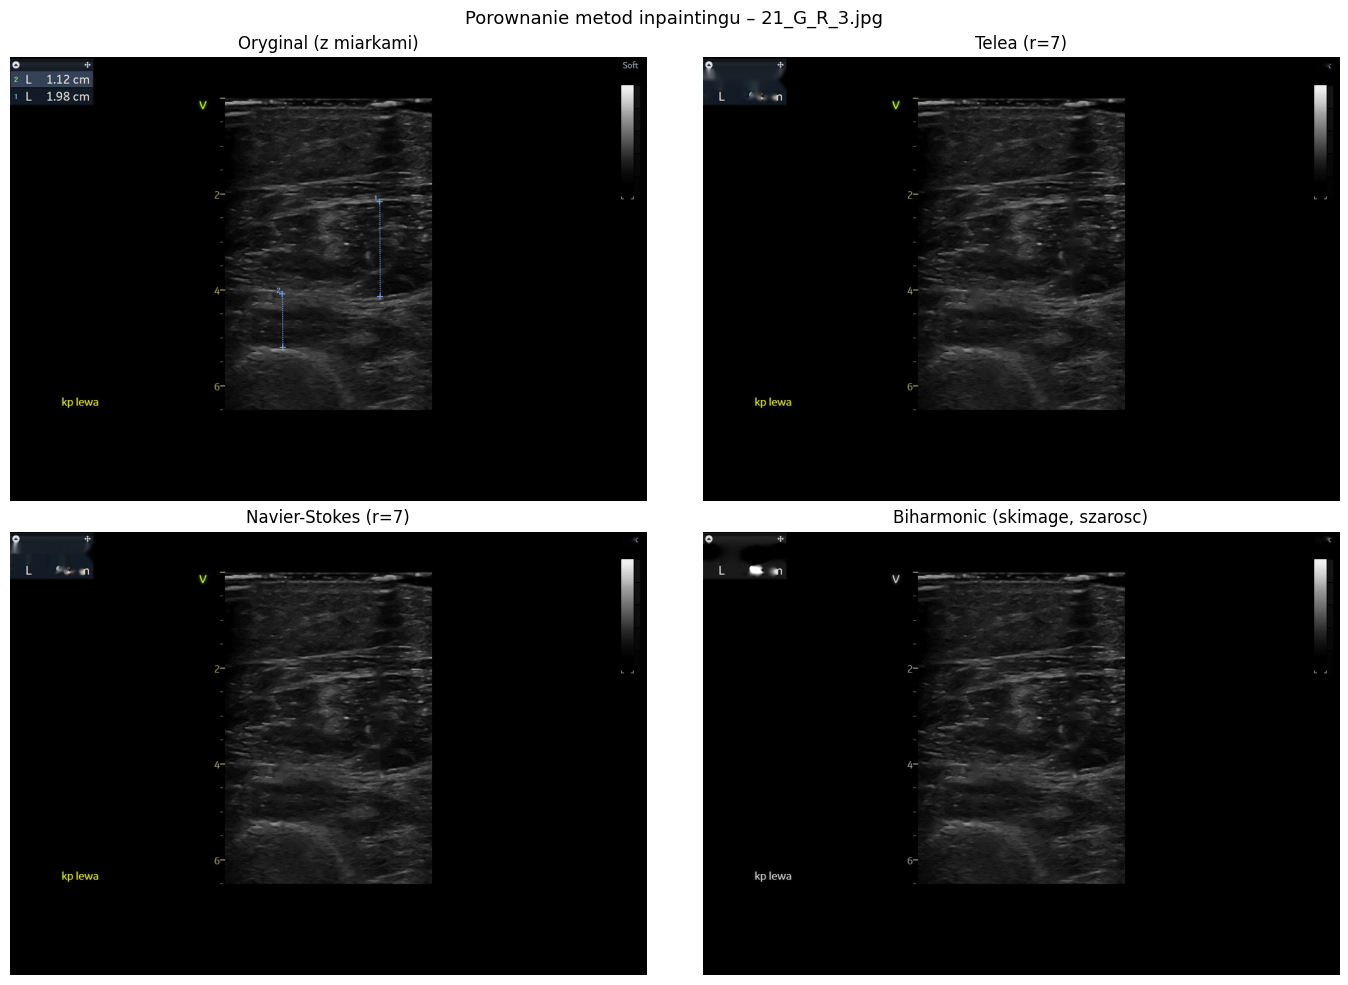

In [26]:
INPAINT_RADIUS = 7

result_telea = cv2.inpaint(img_bgr, mask, INPAINT_RADIUS, cv2.INPAINT_TELEA)
result_ns    = cv2.inpaint(img_bgr, mask, INPAINT_RADIUS, cv2.INPAINT_NS)
gray_f = img_gray.astype(float) / 255.0
result_bih_gray = inpaint_biharmonic(gray_f, mask.astype(bool))
result_bih_u8 = (result_bih_gray * 255).clip(0,255).astype(np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, im, t in zip(axes.flat,
    [img_rgb,
     cv2.cvtColor(result_telea, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(result_ns,    cv2.COLOR_BGR2RGB),
     cv2.cvtColor(result_bih_u8, cv2.COLOR_GRAY2RGB)],
    ['Oryginal (z miarkami)',
     f'Telea (r={INPAINT_RADIUS})',
     f'Navier-Stokes (r={INPAINT_RADIUS})',
     'Biharmonic (skimage, szarosc)']):
    ax.imshow(im); ax.set_title(t, fontsize=12); ax.axis('off')
plt.suptitle('Porownanie metod inpaintingu – 21_G_R_3.jpg', fontsize=13)
plt.tight_layout(); plt.show()

## 5. Przetwarzanie wsadowe – wszystkie 11 obrazow

In [27]:
image_paths = sorted(INPUT_DIR.glob('*.jpg'))

all_results = []
for fp in image_paths:
    img = cv2.imread(str(fp))
    msk = segment_calipers(img, SEG_PARAMS)
    restored = cv2.inpaint(img, msk, INPAINT_RADIUS, cv2.INPAINT_TELEA)
    cv2.imwrite(str(OUTPUT_DIR / f'{fp.stem}_telea.jpg'), restored)
    cv2.imwrite(str(OUTPUT_DIR / f'{fp.stem}_mask.png'),  msk)
    cov = 100 * float(msk.sum()) / (255.0 * msk.size)
    all_results.append({'name': fp.name, 'coverage': cov,
                         'img': img, 'mask': msk, 'restored': restored})
    print(f'  {fp.name:28s}  maska={cov:.3f}%')

  21.G.R 3.jpg                  maska=1.512%
  28.B.T 2.jpg                  maska=1.604%
  28.B.T 6.jpg                  maska=1.585%
  42.SZ.K 2.jpg                 maska=1.433%
  ROK.A.J 1.jpg                 maska=1.736%
  ROK.A.J 2.jpg                 maska=1.720%
  ROK.A.J 3.jpg                 maska=1.704%
  ROK.A.J 4.jpg                 maska=1.711%
  ROK.K.M 1.jpg                 maska=1.689%
  ROK.K.M 5.jpg                 maska=1.710%
  W.BI.M 6.jpg                  maska=1.572%


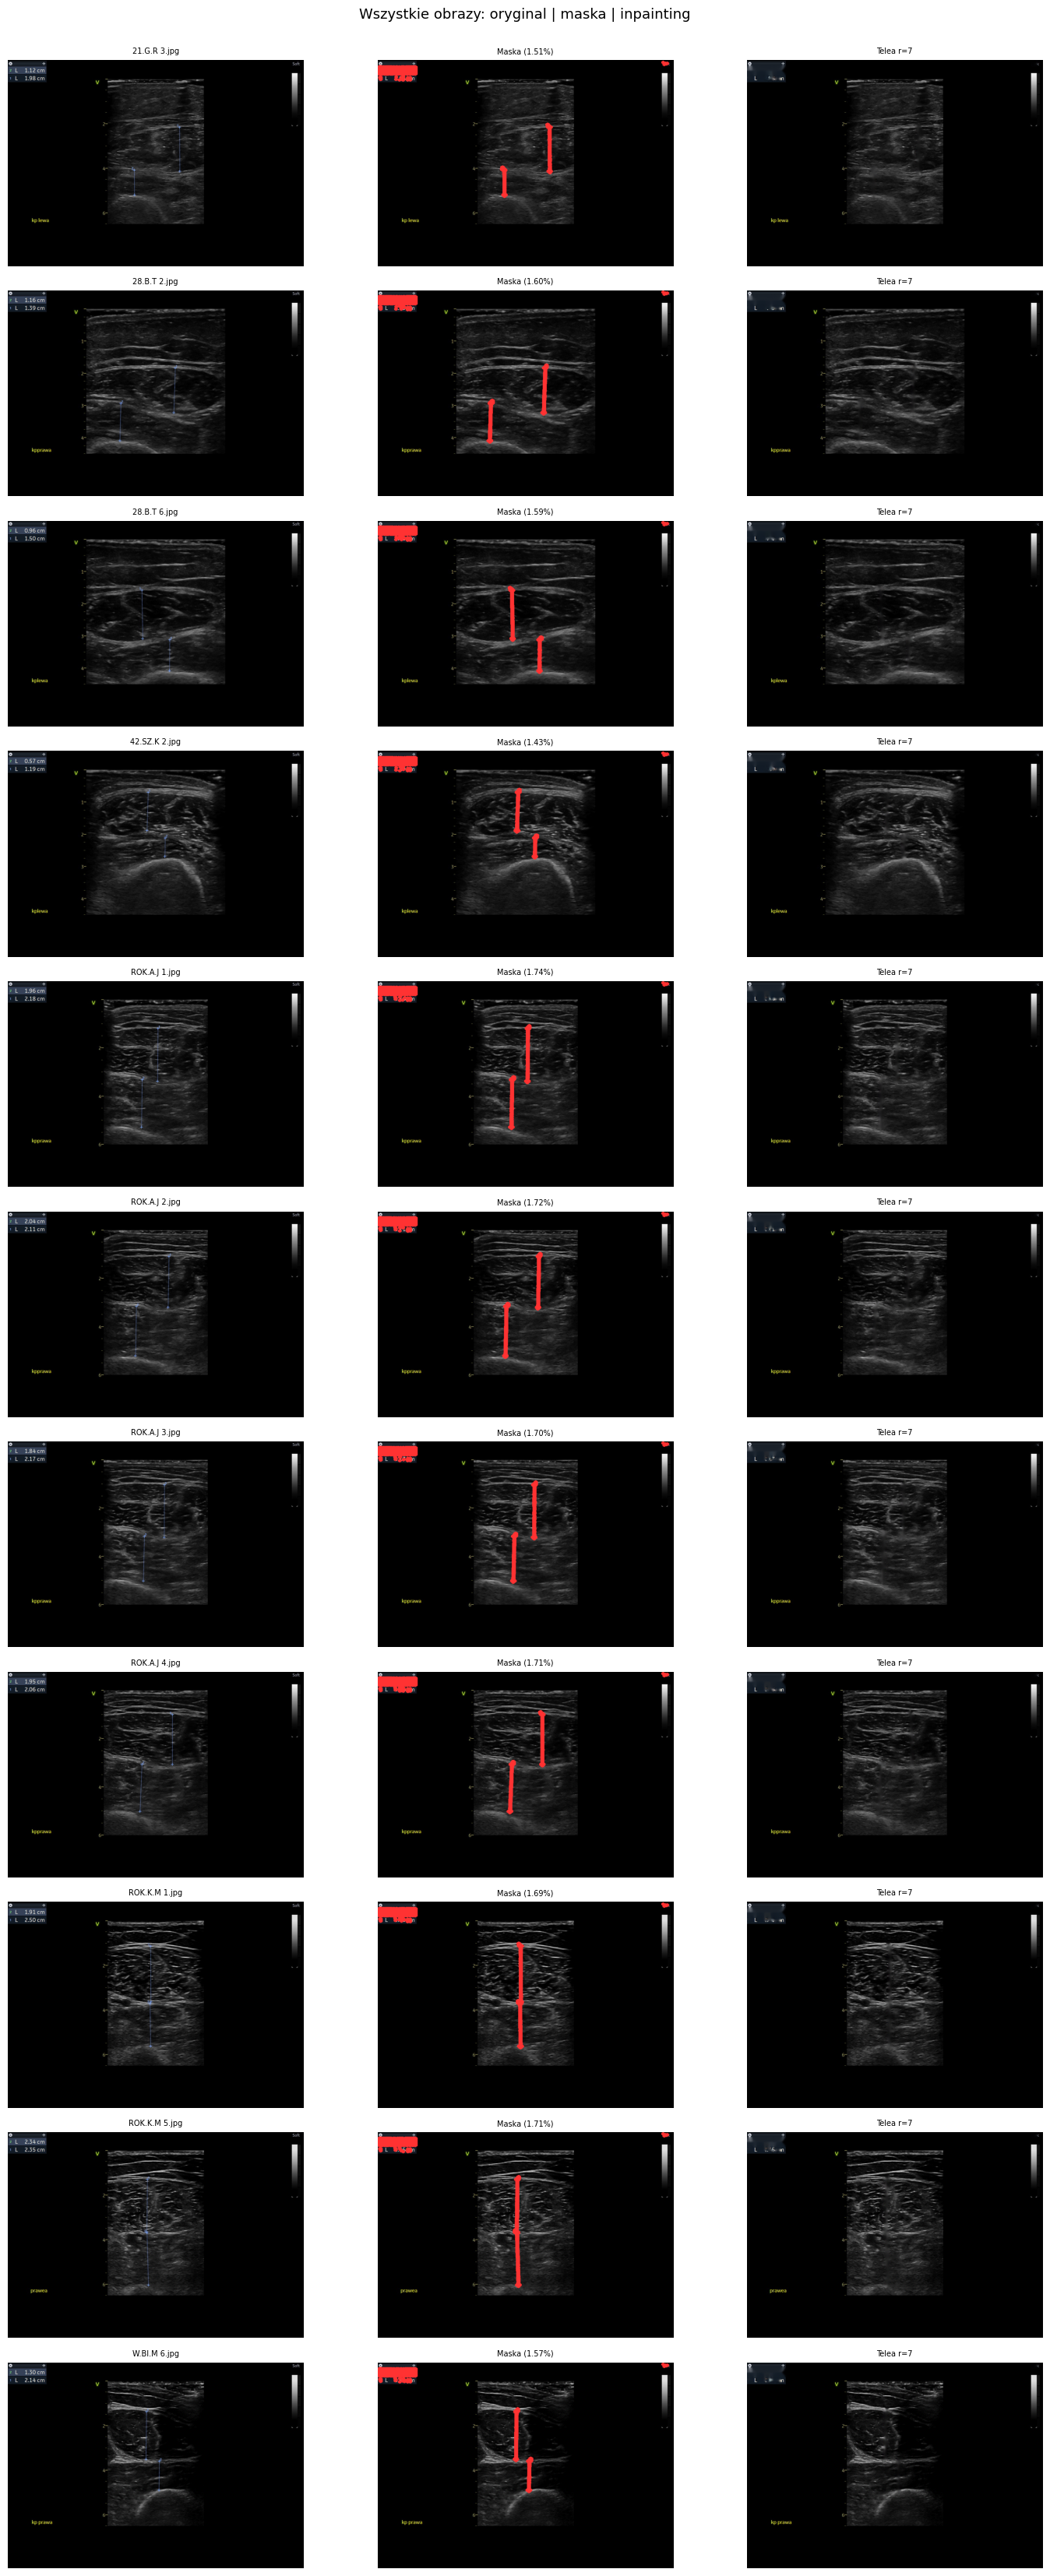

In [28]:
n = len(all_results)
fig, axes = plt.subplots(n, 3, figsize=(15, n*3))
for i, r in enumerate(all_results):
    overlay2 = cv2.cvtColor(r['img'], cv2.COLOR_BGR2RGB).copy()
    overlay2[r['mask']>0] = [255,50,50]
    axes[i,0].imshow(cv2.cvtColor(r['img'],     cv2.COLOR_BGR2RGB))
    axes[i,0].set_title(r['name'], fontsize=7); axes[i,0].axis('off')
    axes[i,1].imshow(overlay2)
    axes[i,1].set_title(f"Maska ({r['coverage']:.2f}%)", fontsize=7); axes[i,1].axis('off')
    axes[i,2].imshow(cv2.cvtColor(r['restored'],cv2.COLOR_BGR2RGB))
    axes[i,2].set_title('Telea r=7', fontsize=7); axes[i,2].axis('off')
plt.suptitle('Wszystkie obrazy: oryginal | maska | inpainting', fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

## 6. Metryki jakosci (bezreferencyjna)

W kazdym z 11 obrazow po inpaintingu wartosci LapVar i GradRMS spadaja, co oznacza mniej sztucznych krawedzi po usunieciu miarek.
Najwieksze spadki LapVar (ok. -106 do -127) widac tam, gdzie artefakty byly najsilniejsze, a brak przypadkow z pogorszeniem potwierdza stabilne dzialanie metody Telea na calym zbiorze.

In [29]:
def compute_metrics(orig_bgr, rest_bgr):
    def lap_var(img):
        g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)
        return float(cv2.Laplacian(g, cv2.CV_64F).var())
    def grad_rms(img):
        g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)
        return float(np.sqrt(
            cv2.Sobel(g,cv2.CV_64F,1,0)**2 +
            cv2.Sobel(g,cv2.CV_64F,0,1)**2).mean())
    return {'LapVar_orig': lap_var(orig_bgr), 'LapVar_inp': lap_var(rest_bgr),
            'GradRMS_orig': grad_rms(orig_bgr), 'GradRMS_inp': grad_rms(rest_bgr)}

metrics_all = []
for r in all_results:
    m = compute_metrics(r['img'], r['restored'])
    m['name'] = r['name']
    metrics_all.append(m)
    print(f"{r['name']:26s}  "
          f"LapVar: {m['LapVar_orig']:5.0f} -> {m['LapVar_inp']:5.0f}  "
          f"(delta={m['LapVar_inp']-m['LapVar_orig']:+.0f})  "
          f"GradRMS: {m['GradRMS_orig']:5.2f} -> {m['GradRMS_inp']:5.2f}")

21.G.R 3.jpg                LapVar:   255 ->   145  (delta=-110)  GradRMS: 14.37 -> 12.54
28.B.T 2.jpg                LapVar:   271 ->   156  (delta=-115)  GradRMS: 19.01 -> 17.12
28.B.T 6.jpg                LapVar:   258 ->   143  (delta=-115)  GradRMS: 17.45 -> 15.50
42.SZ.K 2.jpg               LapVar:   259 ->   153  (delta=-106)  GradRMS: 18.95 -> 17.16
ROK.A.J 1.jpg               LapVar:   278 ->   155  (delta=-123)  GradRMS: 17.04 -> 14.99
ROK.A.J 2.jpg               LapVar:   277 ->   157  (delta=-119)  GradRMS: 16.64 -> 14.65
ROK.A.J 3.jpg               LapVar:   266 ->   157  (delta=-108)  GradRMS: 17.17 -> 15.23
ROK.A.J 4.jpg               LapVar:   267 ->   153  (delta=-114)  GradRMS: 16.82 -> 14.78
ROK.K.M 1.jpg               LapVar:   288 ->   161  (delta=-127)  GradRMS: 20.37 -> 18.14
ROK.K.M 5.jpg               LapVar:   314 ->   204  (delta=-110)  GradRMS: 20.26 -> 18.26
W.BI.M 6.jpg                LapVar:   275 ->   162  (delta=-114)  GradRMS: 14.66 -> 12.77


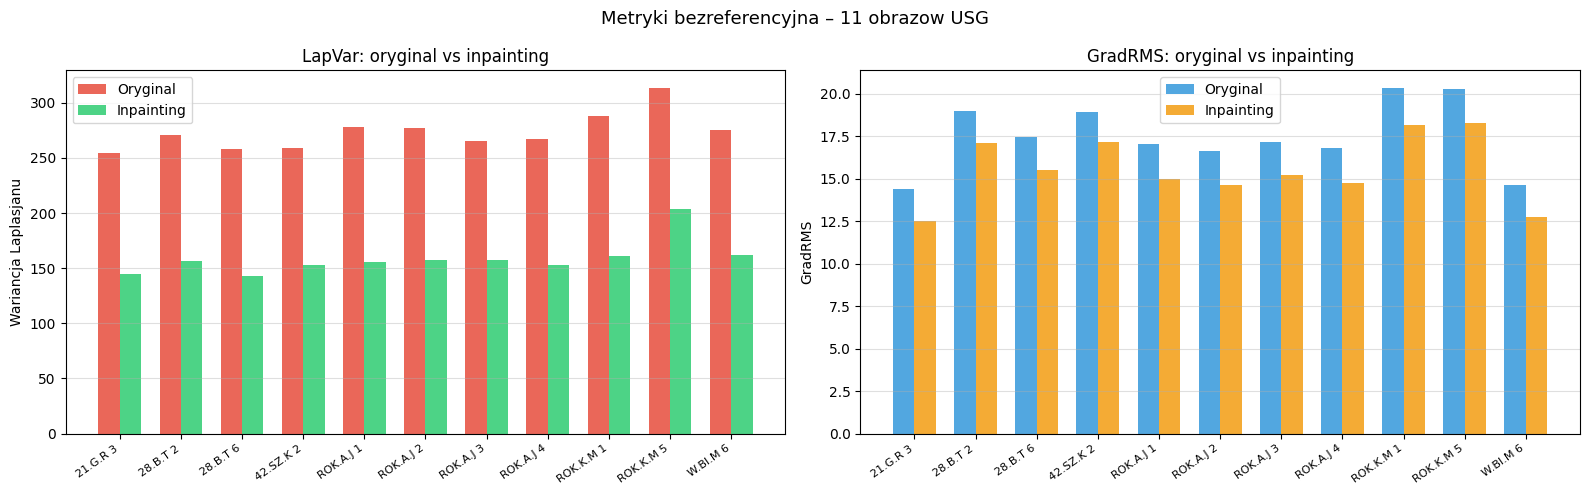

In [30]:
names_s = [m['name'].replace('.jpg','') for m in metrics_all]
x = np.arange(len(names_s)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.bar(x-w/2, [m['LapVar_orig'] for m in metrics_all], w, label='Oryginal', color='#e74c3c', alpha=0.85)
ax.bar(x+w/2, [m['LapVar_inp']  for m in metrics_all], w, label='Inpainting', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names_s, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Wariancja Laplasjanu'); ax.set_title('LapVar: oryginal vs inpainting')
ax.legend(); ax.grid(axis='y', alpha=0.4)

ax2 = axes[1]
ax2.bar(x-w/2, [m['GradRMS_orig'] for m in metrics_all], w, label='Oryginal', color='#3498db', alpha=0.85)
ax2.bar(x+w/2, [m['GradRMS_inp']  for m in metrics_all], w, label='Inpainting', color='#f39c12', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(names_s, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('GradRMS'); ax2.set_title('GradRMS: oryginal vs inpainting')
ax2.legend(); ax2.grid(axis='y', alpha=0.4)

plt.suptitle('Metryki bezreferencyjna – 11 obrazow USG', fontsize=13)
plt.tight_layout(); plt.show()


## 7. Dobor optymalnego promienia

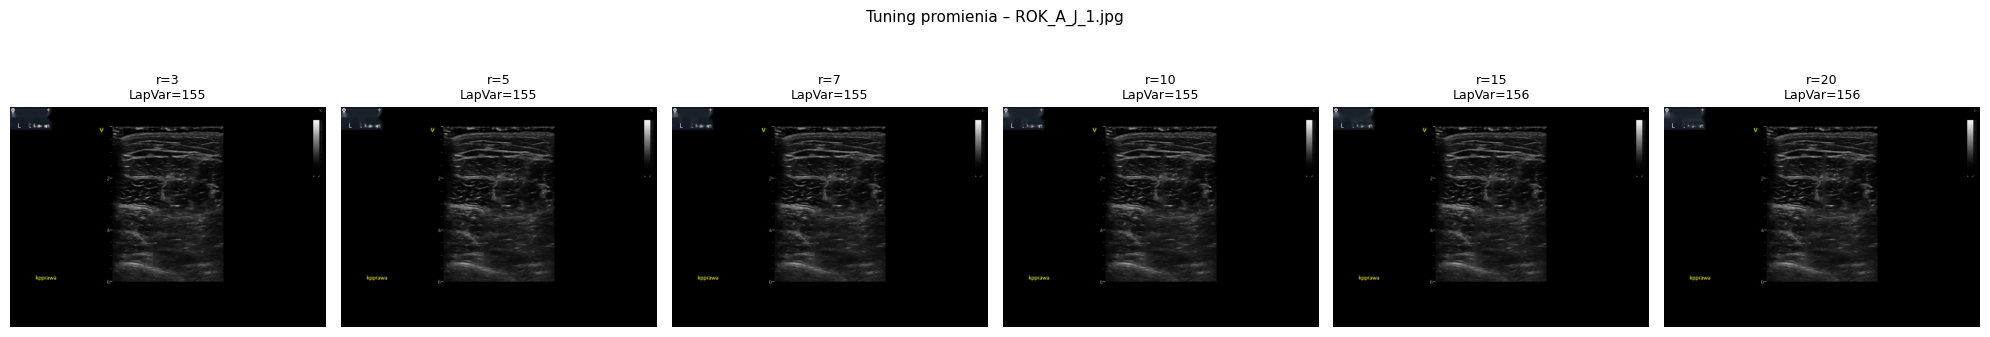

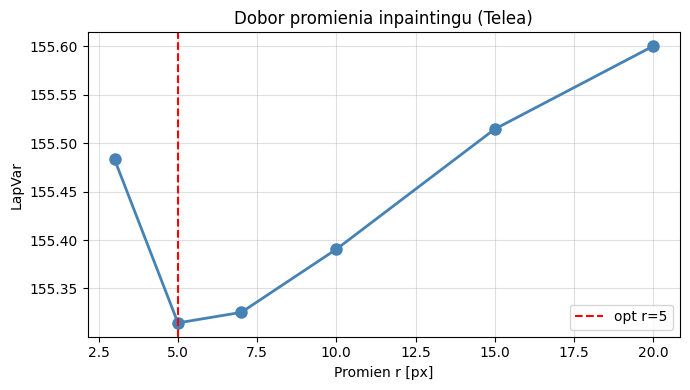

Optymalny promien: r=5  LapVar=155.3


In [33]:
img_test  = cv2.imread(str(INPUT_DIR / 'ROK.A.J 1.jpg'))
mask_test = segment_calipers(img_test, SEG_PARAMS)

radii = [3, 5, 7, 10, 15, 20]
lap_scores = []

fig, axes = plt.subplots(1, len(radii), figsize=(20, 4))
for ax, rad in zip(axes, radii):
    rest = cv2.inpaint(img_test, mask_test, rad, cv2.INPAINT_TELEA)
    g_rest = cv2.cvtColor(rest, cv2.COLOR_BGR2GRAY).astype(float)
    lv = float(cv2.Laplacian(g_rest, cv2.CV_64F).var())
    lap_scores.append(lv)
    ax.imshow(cv2.cvtColor(rest, cv2.COLOR_BGR2RGB))
    ax.set_title(f'r={rad}\nLapVar={lv:.0f}', fontsize=9); ax.axis('off')
plt.suptitle('Tuning promienia – ROK_A_J_1.jpg', fontsize=11)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(radii, lap_scores, 'o-', color='steelblue', lw=2, ms=8)
best_r = radii[int(np.argmin(lap_scores))]
plt.axvline(best_r, color='red', ls='--', label=f'opt r={best_r}')
plt.xlabel('Promien r [px]'); plt.ylabel('LapVar')
plt.title('Dobor promienia inpaintingu (Telea)')
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()
print(f'Optymalny promien: r={best_r}  LapVar={min(lap_scores):.1f}')

## 8. Plansza wynikowa – reprezentatywne przypadki

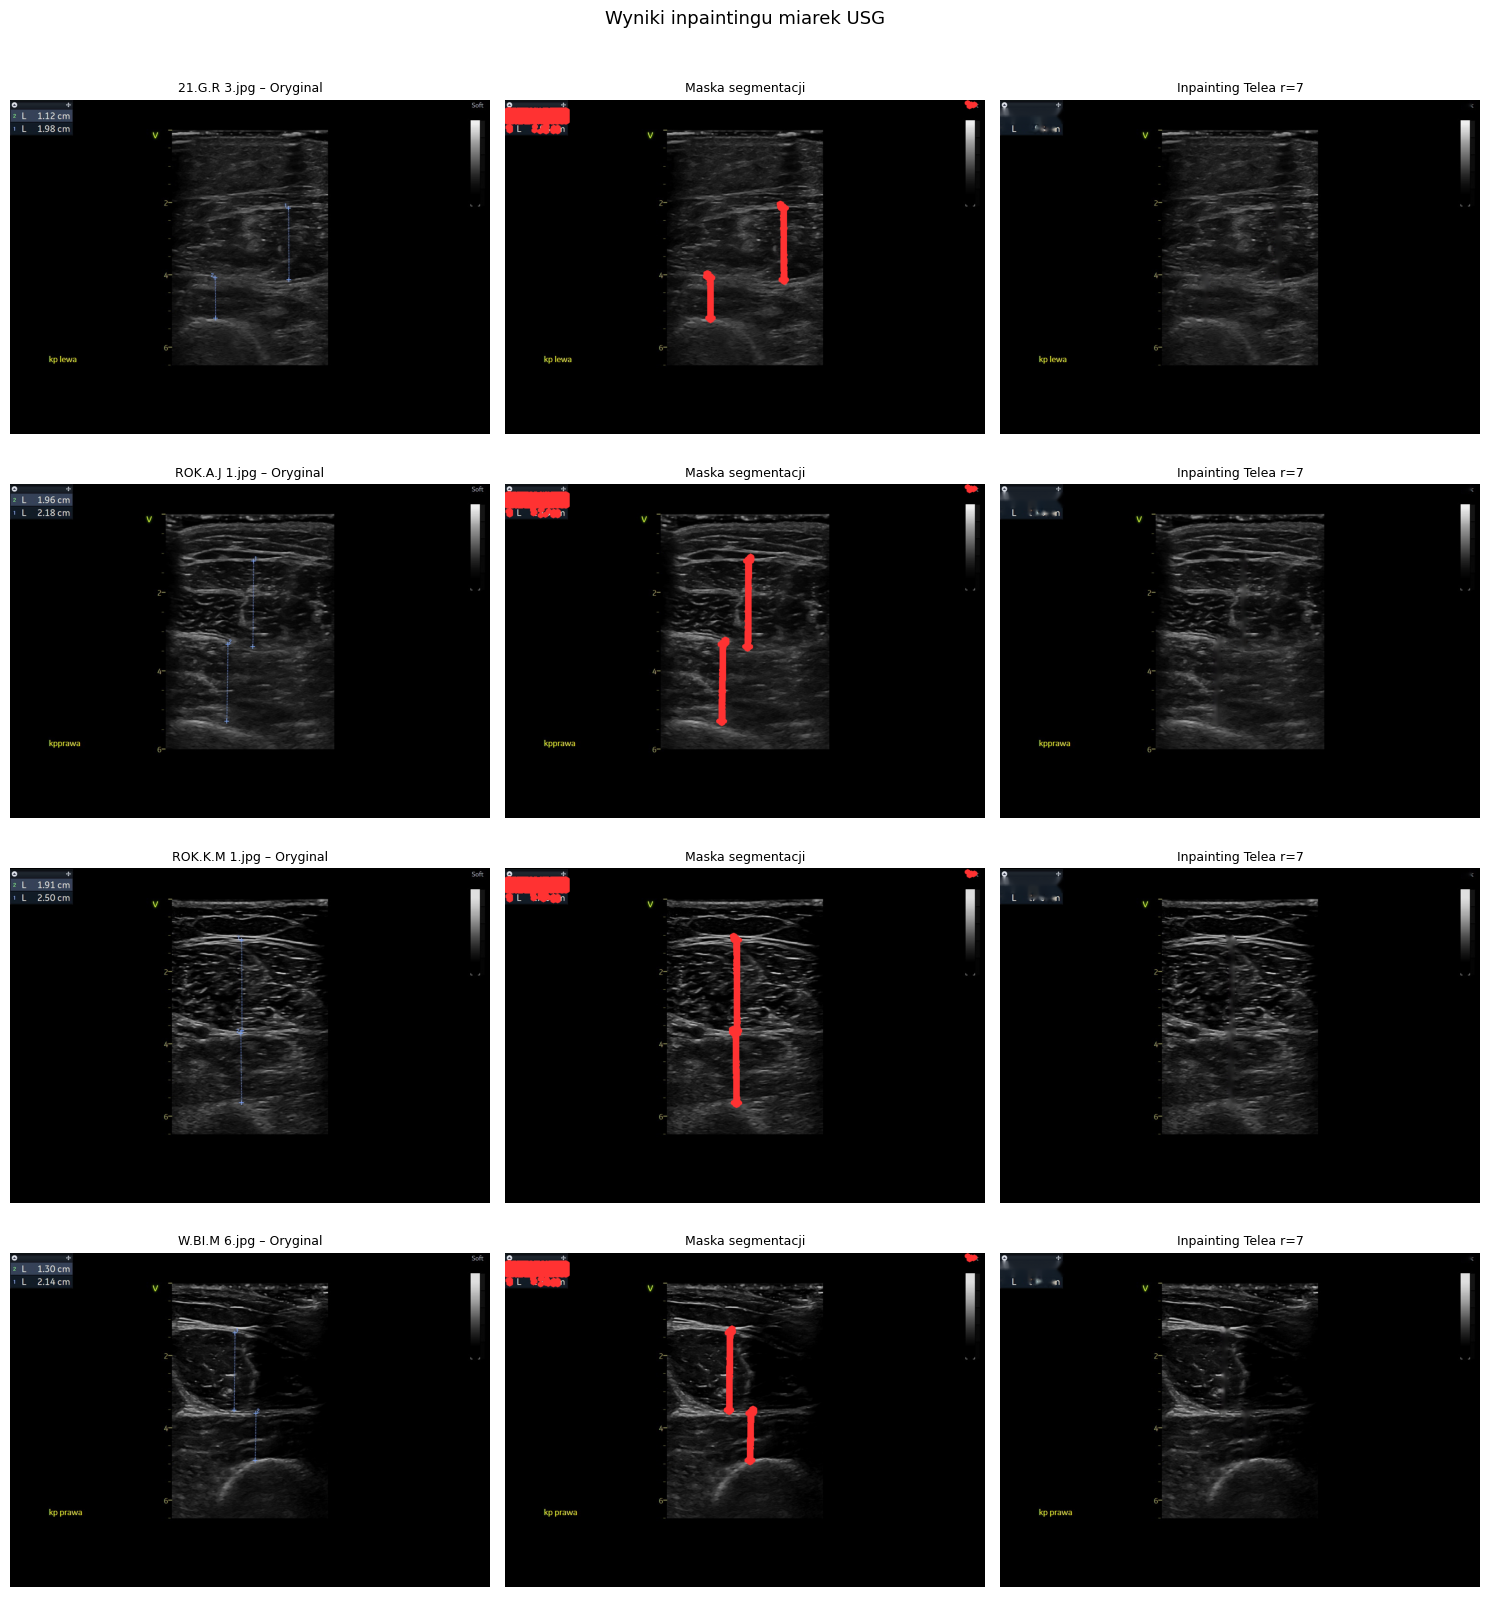

In [35]:
selected = ['21.G.R 3.jpg', 'ROK.A.J 1.jpg', 'ROK.K.M 1.jpg', 'W.BI.M 6.jpg']
fig, axes = plt.subplots(len(selected), 3, figsize=(15, 4*len(selected)))

for row, name in enumerate(selected):
    img = cv2.imread(str(INPUT_DIR / name))
    msk = segment_calipers(img, SEG_PARAMS)
    restored = cv2.inpaint(img, msk, 7, cv2.INPAINT_TELEA)
    overlay2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    overlay2[msk > 0] = [255, 50, 50]
    axes[row,0].imshow(cv2.cvtColor(img,     cv2.COLOR_BGR2RGB))
    axes[row,0].set_title(f'{name} – Oryginal', fontsize=9); axes[row,0].axis('off')
    axes[row,1].imshow(overlay2)
    axes[row,1].set_title('Maska segmentacji', fontsize=9); axes[row,1].axis('off')
    axes[row,2].imshow(cv2.cvtColor(restored,cv2.COLOR_BGR2RGB))
    axes[row,2].set_title('Inpainting Telea r=7', fontsize=9); axes[row,2].axis('off')

plt.suptitle('Wyniki inpaintingu miarek USG', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 9. Zadanie dodatkowe – DNN do inpaintingu

LaMa jest dobrym kandydatem do tego zadania, bo dobrze uzupelnia dlugie i regularne brakujace fragmenty. DeepFill v2 tez moze byc uzyteczny przy wiekszych maskach, a MAT daje wysoka jakosc, ale jest wolniejszy i ciezszy obliczeniowo. Modele dyfuzyjne moga tworzyc nieprawdziwe struktury, dlatego w obrazach medycznych trzeba je traktowac ostroznie. Jesli wybieramy DNN do dalszych testow, LaMa jest najbardziej praktycznym punktem startu.


## Podsumowanie

Segmentacja opiera sie na warunkach B-R>30, B-G>20 i B>80 oraz na dylatacji 7x7 z 2 iteracjami. Maska zajmuje okolo 1.4-1.7% pikseli w 11 obrazach. Inpainting Telea z promieniem r=7 poprawil wyniki we wszystkich przypadkach: LapVar i GradRMS spadly po usunieciu miarek. Czas przetwarzania to okolo 0.1 s na obraz na CPU.